# AI-Powered University Student Support Chatbot

## Final Aligned Notebook
**Pipeline:** Dataset Preparation → Data Cleaning → Hugging Face Embeddings → Semantic Intent Detection → Error Analysis → Intent Prototypes → Targeted Data Improvement

**Important:** Run the notebook from top to bottom. Redundant error-analysis cells from the previous version have been removed, while the useful analysis and prototype pipeline are preserved.


## 1. Dataset Preparation

Load, inspect, clean, and validate the student-support dataset.


In [1]:
# Cell 1: Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Cell 2: Load Dataset

df = pd.read_csv("AI-Powered Chatbot.xlsx - Chatbot_Student_Support.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (200, 10)


In [3]:
# Cell 3: Basic Dataset Inspection

print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


Columns:
['Conversation ID', 'User ID', 'Timestamp', 'User Message', 'Intent', 'Intent Confidence', 'Topic', 'Sentiment Score', 'Sentiment Label', 'Bot Response']

First 5 rows:


,Conversation ID,User ID,Timestamp,User Message,Intent,Intent Confidence,Topic,Sentiment Score,Sentiment Label,Bot Response
0,conv_0001,user_0001,2026-09-01T08:05:12,How do I add a course to my schedule?,course_registration,0.92,Registration,0.10,neutral,"To add a course, go to the student portal > Re..."
1,conv_0002,user_0002,2026-09-01T09:12:45,When is the library open on weekends?,campus_facilities,0.88,Facilities,0.35,positive,The library hours are 9:00–18:00 on Saturdays ...
2,conv_0003,user_0003,2026-09-01T09:45:03,I forgot my student portal password.,technical_issue,0.95,IT Support,-0.20,negative,I can help reset your password. Please visit t...
3,conv_0004,user_0004,2026-09-01T10:02:33,Are there scholarships for international stude...,financial_aid,0.90,Financial Aid,0.25,positive,Yes — we have several scholarships for interna...
4,conv_0005,user_0005,2026-09-01T10:15:50,I need to book an appointment with career serv...,career_services,0.89,Career,0.40,positive,You can book an appointment via the Career Ser...


In [4]:
# Cell 4: Dataset Information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Conversation ID    200 non-null    object 
 1   User ID            200 non-null    object 
 2   Timestamp          200 non-null    object 
 3   User Message       200 non-null    object 
 4   Intent             200 non-null    object 
 5   Intent Confidence  200 non-null    float64
 6   Topic              200 non-null    object 
 7   Sentiment Score    200 non-null    float64
 8   Sentiment Label    200 non-null    object 
 9   Bot Response       200 non-null    object 
dtypes: float64(2), object(8)
memory usage: 15.8+ KB


In [5]:
# Cell 5: Original Backup

df_raw = df.copy()
print("Original dataset shape:", df_raw.shape)


Original dataset shape: (200, 10)


In [6]:
# Cell 6: Missing Values

missing = df_raw.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing values:", missing.sum())


Missing values in each column:
Conversation ID      0
User ID              0
Timestamp            0
User Message         0
Intent               0
Intent Confidence    0
Topic                0
Sentiment Score      0
Sentiment Label      0
Bot Response         0
dtype: int64

Total missing values: 0


In [7]:
# Cell 7: Duplicate Complete Rows

duplicate_rows = df_raw.duplicated().sum()
print("Duplicate complete rows:", duplicate_rows)


Duplicate complete rows: 0


In [8]:
# Cell 8: Duplicate User Questions

duplicate_questions = df_raw["User Message"].duplicated().sum()
print("Duplicate User Messages:", duplicate_questions)

if duplicate_questions > 0:
    display(
        df_raw[df_raw["User Message"].duplicated(keep=False)]
        [["User Message", "Intent", "Bot Response"]]
        .sort_values("User Message")
    )


Duplicate User Messages: 0


In [9]:
# Cell 9: Check for Question → Multiple Intent Conflicts

question_intent_counts = (
    df_raw.groupby("User Message")["Intent"]
    .nunique()
)

conflicting_questions = question_intent_counts[
    question_intent_counts > 1
]

print("Questions having multiple intents:", len(conflicting_questions))

if len(conflicting_questions) > 0:
    for question in conflicting_questions.index:
        print("\n" + "=" * 70)
        print("QUESTION:", question)
        display(
            df_raw[df_raw["User Message"] == question]
            [["User Message", "Intent", "Bot Response"]]
        )


Questions having multiple intents: 0


In [10]:
# Cell 10: Text Cleaning

df_clean = df_raw.copy()

text_columns = [
    "User Message",
    "Intent",
    "Topic",
    "Sentiment Label",
    "Bot Response"
]

for col in text_columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

print("Text cleaning completed.")


Text cleaning completed.


In [11]:
# Cell 11: Verify Cleaning Changes

for col in text_columns:
    changed = (
        df_raw[col].astype(str)
        != df_clean[col].astype(str)
    ).sum()
    print(f"{col}: {changed} rows changed")


User Message: 0 rows changed
Intent: 0 rows changed
Topic: 0 rows changed
Sentiment Label: 0 rows changed
Bot Response: 0 rows changed


In [12]:
# Cell 12: Empty Questions

empty_questions = (
    df_clean["User Message"].isna()
    | (df_clean["User Message"].str.strip() == "")
)

print("Empty questions:", empty_questions.sum())


Empty questions: 0


In [13]:
# Cell 13: Very Short Questions

short_questions = df_clean[
    df_clean["User Message"].str.len() < 10
]

print("Very short questions:", len(short_questions))

display(
    short_questions[
        ["User Message", "Intent", "Bot Response"]
    ]
)


Very short questions: 0


,User Message,Intent,Bot Response


In [14]:
# Cell 14: Intent Distribution

intent_counts = df_clean["Intent"].value_counts()

print("Number of unique intents:", df_clean["Intent"].nunique())
print("\nQuestions per intent:")
print(intent_counts)


Number of unique intents: 26

Questions per intent:
Intent
campus_facilities      23
student_services       20
administration         19
financial_aid          18
student_life           12
course_registration    10
career_services        10
academic_advising      10
academic_policies      10
technical_issue         9
academic_support        8
accessibility           8
research_support        6
safety                  6
course_information      6
housing                 6
mental_health           5
health                  3
study_abroad            2
academic_programs       2
student_employment      2
schedule                1
grades                  1
exam_schedule           1
admissions              1
library                 1
Name: count, dtype: int64


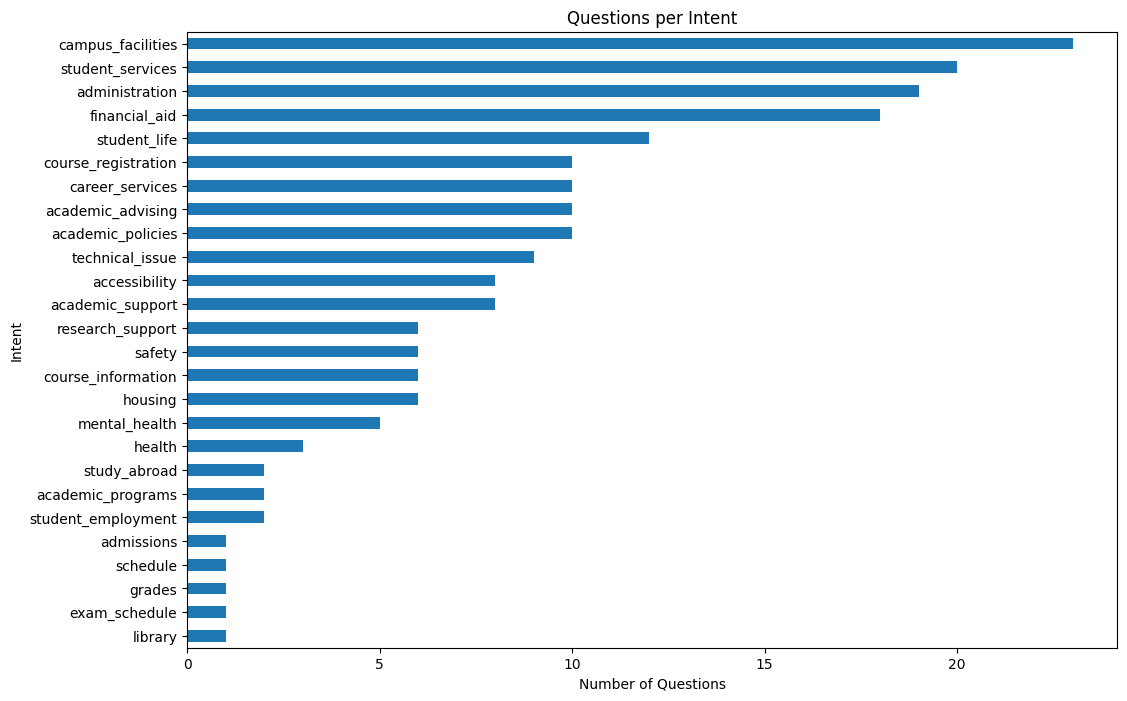

In [15]:
# Cell 15: Intent Distribution Plot

plt.figure(figsize=(12, 8))
intent_counts.sort_values().plot(kind="barh")
plt.title("Questions per Intent")
plt.xlabel("Number of Questions")
plt.ylabel("Intent")
plt.show()


In [16]:
# Cell 16: Low-Frequency Intents

low_intents = intent_counts[intent_counts < 5]

print("Low-frequency intents (<5 examples):")
print(low_intents)


Low-frequency intents (<5 examples):
Intent
health                3
study_abroad          2
academic_programs     2
student_employment    2
schedule              1
grades                1
exam_schedule         1
admissions            1
library               1
Name: count, dtype: int64


In [17]:
# Cell 17: Inspect Low-Frequency Intents

for intent in low_intents.index:
    print("\n" + "=" * 60)
    print("INTENT:", intent)

    examples = df_clean[
        df_clean["Intent"] == intent
    ]["User Message"].tolist()

    for i, example in enumerate(examples, 1):
        print(f"{i}. {example}")



INTENT: health
1. What COVID policies are currently in effect?
2. Where can I get immunizations required by the university?
3. How to submit proof of vaccination?

INTENT: study_abroad
1. Can I take a leave to study abroad for a semester?
2. What study abroad prerequisites exist?

INTENT: academic_programs
1. Is there an honors program?
2. Can I switch into the honors seminar?

INTENT: student_employment
1. How do I file a workplace complaint for my on-campus job?
2. Are part-time students eligible for on-campus jobs?

INTENT: schedule
1. What's the timetable for next week?

INTENT: grades
1. My grades haven't been updated yet.

INTENT: exam_schedule
1. What are the exam dates for CS101?

INTENT: admissions
1. What's the deadline to submit transcripts from another institution?

INTENT: library
1. How to get textbooks on reserve?


In [18]:
# Cell 18: Bot Response Quality Checks

empty_responses = (
    df_clean["Bot Response"].isna()
    | (df_clean["Bot Response"].str.strip() == "")
)

print("Empty bot responses:", empty_responses.sum())

short_responses = df_clean[
    df_clean["Bot Response"].str.len() < 20
]

print("Very short bot responses:", len(short_responses))
display(
    short_responses[
        ["User Message", "Intent", "Bot Response"]
    ]
)


Empty bot responses: 0
Very short bot responses: 0


,User Message,Intent,Bot Response


In [19]:
# Cell 19: Manual Question → Intent → Response Review

review_df = df_clean[
    ["User Message", "Intent", "Bot Response"]
].sort_values("Intent")

display(review_df)


,User Message,Intent,Bot Response
103,How do I petition for credit transfer?,academic_advising,Submit a Transfer Credit Petition with course ...
115,Can I change my thesis advisor?,academic_advising,Changing advisors requires approval from your ...
22,How do I declare a minor?,academic_advising,"To declare a minor, submit the Minor Declarati..."
52,Can I speak to an academic advisor now?,academic_advising,Advisors have scheduled hours; I can show next...
20,Can I audit a class this semester?,academic_advising,Auditing is allowed for certain courses with i...
...,...,...,...
46,How do I reset two-factor authentication?,technical_issue,Resetting 2FA requires contacting IT or using ...
2,I forgot my student portal password.,technical_issue,I can help reset your password. Please visit t...
21,My laptop won't connect to the projector.,technical_issue,Try restarting your laptop and checking the HD...
16,My campus card isn't working at the dining hall.,technical_issue,Card access issues are usually resolved by Car...


In [20]:
# Cell 20: Final Clean Dataset Check

print("========== FINAL DATASET CHECK ==========")
print("Shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())
print("\nDuplicate complete rows:", df_clean.duplicated().sum())
print("Duplicate questions:", df_clean["User Message"].duplicated().sum())
print("Unique intents:", df_clean["Intent"].nunique())


========== FINAL DATASET CHECK ==========
Shape: (200, 10)

Missing values:
Conversation ID      0
User ID              0
Timestamp            0
User Message         0
Intent               0
Intent Confidence    0
Topic                0
Sentiment Score      0
Sentiment Label      0
Bot Response         0
dtype: int64

Duplicate complete rows: 0
Duplicate questions: 0
Unique intents: 26


## 2. Hugging Face Embeddings

Use Sentence Transformers to convert user questions into semantic vectors.


In [21]:
# Cell 21: Hugging Face / Sentence Transformers
# sentence-transformers is already installed in the current environment.

from sentence_transformers import SentenceTransformer


In [23]:
# Cell 22: Load Hugging Face Model

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Hugging Face model loaded successfully!")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Hugging Face model loaded successfully!


In [24]:
# Cell 23: Test Embeddings

sentences = [
    "How do I register for a course?",
    "How can I enroll in a subject?"
]

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)


Embedding shape: (2, 384)


In [25]:
# Cell 24: Test Cosine Similarity

similarity = cosine_similarity(
    [embeddings[0]],
    [embeddings[1]]
)[0][0]

print("Similarity:", similarity)


Similarity: 0.6822021


In [26]:
# Cell 25: Generate Embeddings for CLEAN Dataset

questions = df_clean["User Message"].tolist()

question_embeddings = model.encode(
    questions,
    show_progress_bar=True
)

print("Number of questions:", len(questions))
print("Embedding shape:", question_embeddings.shape)


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Number of questions: 200
Embedding shape: (200, 384)


## 3. Baseline Semantic Intent Detection

Evaluate nearest-question semantic intent detection before prototype modeling.


In [27]:
# Cell 26: Semantic Search

def search_similar_question(user_question, top_k=5):
    user_embedding = model.encode([user_question])

    similarities = cosine_similarity(
        user_embedding,
        question_embeddings
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = df_clean.iloc[top_indices].copy()
    results["Similarity"] = similarities[top_indices]

    return results


In [28]:
# Cell 27: Test Semantic Search

results = search_similar_question(
    "How can I register for a course?"
)

display(
    results[["User Message", "Intent", "Bot Response", "Similarity"]]
)


,User Message,Intent,Bot Response,Similarity
138,How to find course prerequisites?,course_information,Prerequisites are listed in the Course Catalog...,0.625680
0,How do I add a course to my schedule?,course_registration,"To add a course, go to the student portal > Re...",0.625238
153,How to register for language classes?,course_registration,Register via Registration; language classes ha...,0.623187
71,How do I enroll in summer classes?,course_registration,Summer enrollment opens on the Registration pa...,0.576252
125,What's the process for filing a complaint abou...,academic_policies,File a formal complaint with the Academic Affa...,0.549601


In [29]:
# Cell 28: Intent Detection

def detect_intent(user_question, top_k=5):
    results = search_similar_question(
        user_question,
        top_k
    )

    intent_scores = defaultdict(float)

    for _, row in results.iterrows():
        intent_scores[row["Intent"]] += row["Similarity"]

    predicted_intent = max(
        intent_scores,
        key=intent_scores.get
    )

    return predicted_intent, results, dict(intent_scores)


In [30]:
# Cell 29: Test Intent Detection

question = "How can I register for a course?"

intent, results, scores = detect_intent(question)

print("Question:", question)
print("Predicted Intent:", intent)

print("\nIntent Scores:")
for intent_name, score in sorted(
    scores.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(intent_name, ":", round(score, 4))


Question: How can I register for a course?
Predicted Intent: course_registration

Intent Scores:
course_registration : 1.8247
course_information : 0.6257
academic_policies : 0.5496


In [31]:
# Cell 30: Test Multiple Questions

test_questions = [
    "How can I register for a course?",
    "How do I enroll in a class?",
    "Where can I see my grades?",
    "How can I reset my password?",
    "How do I contact the university?"
]

for question in test_questions:
    intent, _, _ = detect_intent(question)
    print("=" * 70)
    print("Question:", question)
    print("Predicted Intent:", intent)


Question: How can I register for a course?
Predicted Intent: course_registration
Question: How do I enroll in a class?
Predicted Intent: course_registration
Question: Where can I see my grades?
Predicted Intent: administration
Question: How can I reset my password?
Predicted Intent: technical_issue
Question: How do I contact the university?
Predicted Intent: administration


In [32]:
# Cell 31: Leave-One-Out Evaluation

def predict_intent_leave_one_out(index):
    user_question = df_clean.iloc[index]["User Message"]
    actual_intent = df_clean.iloc[index]["Intent"]

    user_embedding = model.encode([user_question])

    mask = np.arange(len(df_clean)) != index

    other_embeddings = question_embeddings[mask]
    other_df = df_clean.iloc[mask]

    similarities = cosine_similarity(
        user_embedding,
        other_embeddings
    )[0]

    top_indices = similarities.argsort()[-5:][::-1]

    intent_scores = defaultdict(float)

    for idx in top_indices:
        intent = other_df.iloc[idx]["Intent"]
        intent_scores[intent] += similarities[idx]

    predicted_intent = max(
        intent_scores,
        key=intent_scores.get
    )

    return actual_intent, predicted_intent


In [33]:
# Cell 32: Baseline Evaluation

actual_labels = []
predicted_labels = []

for i in range(len(df_clean)):
    actual, predicted = predict_intent_leave_one_out(i)
    actual_labels.append(actual)
    predicted_labels.append(predicted)

accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

correct = sum(
    a == p
    for a, p in zip(actual_labels, predicted_labels)
)

print("Total questions:", len(df_clean))
print("Correct predictions:", correct)
print("Accuracy:", round(accuracy * 100, 2), "%")


Total questions: 200
Correct predictions: 117
Accuracy: 58.5 %


In [34]:
# Cell 33: Error Analysis

errors = []

for i in range(len(df_clean)):
    actual, predicted = predict_intent_leave_one_out(i)

    if actual != predicted:
        errors.append({
            "Question": df_clean.iloc[i]["User Message"],
            "Actual Intent": actual,
            "Predicted Intent": predicted
        })

error_df = pd.DataFrame(errors)

print("Total errors:", len(error_df))
display(error_df.head(20))


Total errors: 83


,Question,Actual Intent,Predicted Intent
0,What are the exam dates for CS101?,exam_schedule,course_information
1,My grades haven't been updated yet.,grades,academic_policies
2,I'm feeling anxious about finals.,mental_health,campus_facilities
3,Is there on-campus housing available next seme...,housing,campus_facilities
4,Who do I contact about accessibility services?,student_services,accessibility
5,Can I get an extension on my assignment?,academic_policies,course_registration
6,Can I audit a class this semester?,academic_advising,course_information
7,How do I declare a minor?,academic_advising,administration
8,Where can I find the syllabus for MATH201?,course_information,student_services
9,How many credits do I need to graduate?,academic_advising,career_services


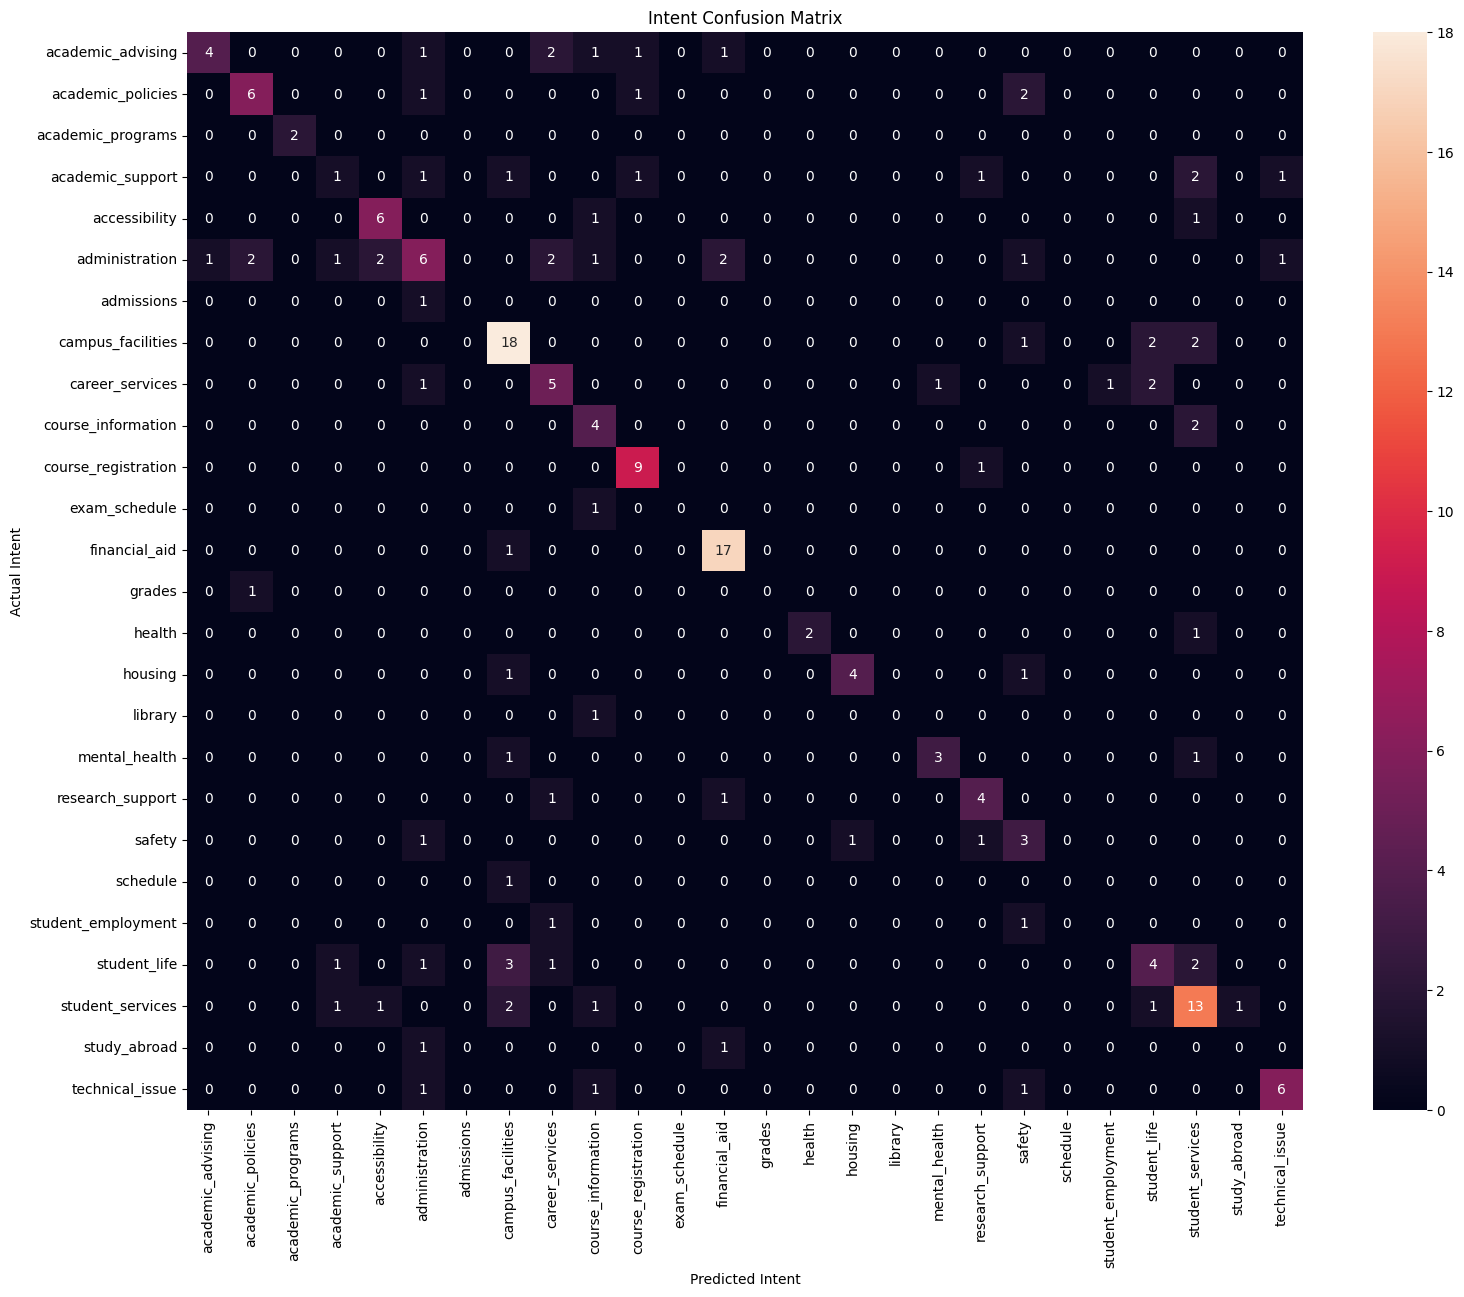

In [35]:
# Cell 34: Confusion Matrix

labels = sorted(df_clean["Intent"].unique())

cm = confusion_matrix(
    actual_labels,
    predicted_labels,
    labels=labels
)

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.title("Intent Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


## 4. Baseline Error Analysis

Keep one clear copy of each useful error-analysis step; duplicate cells from the previous notebook are removed.


In [36]:
# Cell 35: Build Incorrect-Prediction DataFrame

# Find incorrect predictions

error_df = df_clean.copy()

error_df["Actual Intent"] = actual_labels
error_df["Predicted Intent"] = predicted_labels

errors = error_df[
    error_df["Actual Intent"] != error_df["Predicted Intent"]
].copy()

print("Total questions:", len(error_df))
print("Incorrect predictions:", len(errors))
print(
    "Error rate:",
    round(len(errors) / len(error_df) * 100, 2),
    "%"
)


Total questions: 200
Incorrect predictions: 83
Error rate: 41.5 %


In [37]:
# Cell 36: Display Incorrect Predictions

display(
    errors[
        [
            "User Message",
            "Actual Intent",
            "Predicted Intent",
            "Bot Response"
        ]
    ]
)


,User Message,Actual Intent,Predicted Intent,Bot Response
5,What are the exam dates for CS101?,exam_schedule,course_information,Exam dates are posted on the course page. For ...
6,My grades haven't been updated yet.,grades,academic_policies,Grades are uploaded by instructors and can tak...
7,I'm feeling anxious about finals.,mental_health,campus_facilities,I'm sorry you're feeling anxious. The counseli...
10,Is there on-campus housing available next seme...,housing,campus_facilities,Housing availability varies. Check the Housing...
13,Who do I contact about accessibility services?,student_services,accessibility,Contact the Accessibility Services Office at a...
...,...,...,...,...
190,Is there a policy on fraternities/sororities?,student_life,student_services,Greek Life policies are on Student Affairs pag...
191,How to report a bug in the student app?,technical_issue,safety,Report bugs via the IT Helpdesk with steps to ...
192,Are there campus job fairs coming up?,career_services,student_life,Yes — job fairs are scheduled this semester. I...
193,How to get textbooks on reserve?,library,course_information,Request reserve placement through your course ...


In [38]:
# Cell 37: Errors by Actual Intent

error_summary = errors["Actual Intent"].value_counts()

print("Errors by actual intent:")
print(error_summary)


Errors by actual intent:
Actual Intent
administration         13
student_life            8
student_services        7
academic_support        7
academic_advising       6
campus_facilities       5
career_services         5
academic_policies       4
technical_issue         3
safety                  3
study_abroad            2
student_employment      2
accessibility           2
research_support        2
course_information      2
housing                 2
mental_health           2
health                  1
admissions              1
exam_schedule           1
course_registration     1
financial_aid           1
grades                  1
schedule                1
library                 1
Name: count, dtype: int64


In [39]:
# Cell 38: Confusion Pairs

confusion_pairs = (
    errors
    .groupby(
        ["Actual Intent", "Predicted Intent"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(confusion_pairs)


,Actual Intent,Predicted Intent,Count
54,student_life,campus_facilities,3
19,administration,accessibility,2
59,student_services,campus_facilities,2
20,administration,career_services,2
27,campus_facilities,student_life,2
...,...,...,...
31,career_services,student_employment,1
35,exam_schedule,course_information,1
36,financial_aid,campus_facilities,1
37,grades,academic_policies,1


In [40]:
# Cell 39: Export Error Analysis

errors.to_csv(
    "chatbot_error_analysis.csv",
    index=False
)

print("Error analysis saved successfully.")


Error analysis saved successfully.


In [41]:
# Cell 40: Intent-Level Baseline Performance

intent_total = (
    df_clean["Intent"]
    .value_counts()
    .rename_axis("Intent")
    .reset_index(name="Total")
)

intent_errors = (
    errors["Actual Intent"]
    .value_counts()
    .rename_axis("Intent")
    .reset_index(name="Errors")
)

intent_performance = intent_total.merge(
    intent_errors,
    on="Intent",
    how="left"
)

intent_performance["Errors"] = (
    intent_performance["Errors"]
    .fillna(0)
    .astype(int)
)

intent_performance["Error %"] = (
    intent_performance["Errors"]
    / intent_performance["Total"]
    * 100
).round(2)

display(
    intent_performance.sort_values(
        "Error %",
        ascending=False
    )
)


,Intent,Total,Errors,Error %
25,library,1,1,100.00
18,study_abroad,2,2,100.00
24,admissions,1,1,100.00
23,exam_schedule,1,1,100.00
22,grades,1,1,100.00
21,schedule,1,1,100.00
20,student_employment,2,2,100.00
10,academic_support,8,7,87.50
2,administration,19,13,68.42
4,student_life,12,8,66.67


In [42]:
# Cell 41: Identify Weak Intents

# Calculate Accuracy from Error %
intent_performance["Accuracy"] = 100 - intent_performance["Error %"]

# Find intents with accuracy below 50%
weak_intents = intent_performance[
    intent_performance["Accuracy"] < 50
]["Intent"].tolist()

print("Weak intents:")

for intent in weak_intents:
    print("-", intent)


Weak intents:
- administration
- student_life
- academic_advising
- academic_support
- study_abroad
- student_employment
- schedule
- grades
- exam_schedule
- admissions
- library


In [43]:
# Cell 42: Inspect Weak Intent Examples

for intent in weak_intents:
    print("\n" + "=" * 70)
    print("INTENT:", intent)
    
    examples = df[df["Intent"] == intent]["User Message"].tolist()
    
    for i, example in enumerate(examples, 1):
        print(f"{i}. {example}")



INTENT: administration
1. How do I apply for a transcript?
2. Can the bot submit a leave of absence?
3. What's the procedure for medical leave?
4. Can I get a letter verifying my enrollment?
5. What resources are there for international student visas?
6. How do I update my personal information?
7. Can I see last semester's transcript online?
8. How to contact the registrar?
9. Can I get an official ID replacement?
10. How to add an emergency contact?
11. Can I request a meeting with the dean?
12. How do I withdraw from the university?
13. What are the steps to apply for graduation?
14. Can I defer my enrollment?
15. Can I change my billing address?
16. Can I appeal a disciplinary decision?
17. Can I get a waiver for health insurance?
18. Where do I pick up my student ID?
19. What are acceptable ID forms for exams?

INTENT: student_life
1. How do I join the robotics club?
2. Who do I contact about campus events?
3. Do we have language exchange partners?
4. Can I schedule a campus tour 

In [44]:
# Cell 43: Weak Intent Confusion Analysis

weak_confusions = (
    error_df[error_df["Actual Intent"].isin(weak_intents)]
    .groupby(["Actual Intent", "Predicted Intent"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(weak_confusions)


,Actual Intent,Predicted Intent,Count
17,administration,administration,6
0,academic_advising,academic_advising,4
34,student_life,student_life,4
32,student_life,campus_facilities,3
14,administration,academic_policies,2
20,administration,financial_aid,2
18,administration,career_services,2
16,administration,accessibility,2
11,academic_support,student_services,2
35,student_life,student_services,2


## 5. Intent Prototype Classifier

Create one semantic prototype per intent and evaluate prototype-based classification.


In [45]:
# Cell 44: Create Intent Prototypes

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Store one prototype embedding for each intent
intent_prototypes = {}

for intent in df_clean["Intent"].unique():
    
    # Get all embeddings belonging to this intent
    intent_indices = df_clean[
        df_clean["Intent"] == intent
    ].index
    
    intent_vectors = question_embeddings[
        intent_indices
    ]
    
    # Average all embeddings of this intent
    prototype = np.mean(intent_vectors, axis=0)
    
    # Normalize prototype
    prototype = prototype / np.linalg.norm(prototype)
    
    intent_prototypes[intent] = prototype

print("Number of intent prototypes:", len(intent_prototypes))
print("Prototype dimension:", next(iter(intent_prototypes.values())).shape)


Number of intent prototypes: 26
Prototype dimension: (384,)


In [46]:
# Cell 45: Prototype Prediction Function

def predict_intent_prototype(user_question):
    
    # Convert question into embedding
    user_embedding = model.encode(
        [user_question],
        normalize_embeddings=True
    )
    
    scores = {}
    
    # Compare with every intent prototype
    for intent, prototype in intent_prototypes.items():
        
        similarity = cosine_similarity(
            user_embedding,
            prototype.reshape(1, -1)
        )[0][0]
        
        scores[intent] = similarity
    
    # Highest similarity
    predicted_intent = max(
        scores,
        key=scores.get
    )
    
    return predicted_intent, scores


In [47]:
# Cell 46: Test Prototype Classifier

test_questions = [
    "What are the exam dates for CS101?",
    "My grades haven't been updated yet.",
    "How do I register for a course?",
    "I forgot my student portal password.",
    "Is there on-campus housing?"
]

for question in test_questions:
    
    intent, scores = predict_intent_prototype(question)
    
    print("=" * 70)
    print("Question:", question)
    print("Predicted Intent:", intent)


Question: What are the exam dates for CS101?
Predicted Intent: exam_schedule
Question: My grades haven't been updated yet.
Predicted Intent: grades
Question: How do I register for a course?
Predicted Intent: course_registration
Question: I forgot my student portal password.
Predicted Intent: technical_issue
Question: Is there on-campus housing?
Predicted Intent: housing


In [82]:
# Cell 47: Evaluate Prototype Classifier

prototype_actual = []
prototype_predicted = []

for _, row in df_clean.iterrows():

    question = row["User Message"]
    actual_intent = row["Intent"]

    predicted_intent, _ = predict_intent_prototype(question)

    prototype_actual.append(actual_intent)
    prototype_predicted.append(predicted_intent)


# Calculate accuracy
correct = sum(
    actual == predicted
    for actual, predicted
    in zip(prototype_actual, prototype_predicted)
)

total = len(prototype_actual)

accuracy = correct / total * 100

print("Total questions:", total)
print("Correct predictions:", correct)
print("Incorrect predictions:", total - correct)
print("Prototype Accuracy:", round(accuracy, 2), "%")


Total questions: 200
Correct predictions: 178
Incorrect predictions: 22
Prototype Accuracy: 89.0 %


In [83]:
# Cell 48: Inspect Response Data

print("Dataset columns:")
print(df_clean.columns.tolist())

print("\nSample rows:")
display(df_clean.head())

Dataset columns:
['Conversation ID', 'User ID', 'Timestamp', 'User Message', 'Intent', 'Intent Confidence', 'Topic', 'Sentiment Score', 'Sentiment Label', 'Bot Response']

Sample rows:


,Conversation ID,User ID,Timestamp,User Message,Intent,Intent Confidence,Topic,Sentiment Score,Sentiment Label,Bot Response
0,conv_0001,user_0001,2026-09-01T08:05:12,How do I add a course to my schedule?,course_registration,0.92,Registration,0.10,neutral,"To add a course, go to the student portal > Re..."
1,conv_0002,user_0002,2026-09-01T09:12:45,When is the library open on weekends?,campus_facilities,0.88,Facilities,0.35,positive,The library hours are 9:00–18:00 on Saturdays ...
2,conv_0003,user_0003,2026-09-01T09:45:03,I forgot my student portal password.,technical_issue,0.95,IT Support,-0.20,negative,I can help reset your password. Please visit t...
3,conv_0004,user_0004,2026-09-01T10:02:33,Are there scholarships for international stude...,financial_aid,0.90,Financial Aid,0.25,positive,Yes — we have several scholarships for interna...
4,conv_0005,user_0005,2026-09-01T10:15:50,I need to book an appointment with career serv...,career_services,0.89,Career,0.40,positive,You can book an appointment via the Career Ser...


In [84]:
# Cell 48: Build Intent-Response Mapping

intent_responses = (
    df_clean[["Intent", "Bot Response"]]
    .drop_duplicates(subset=["Intent"])
    .set_index("Intent")["Bot Response"]
    .to_dict()
)

print("Number of intent responses:", len(intent_responses))

for intent, response in list(intent_responses.items())[:5]:
    print("\nIntent:", intent)
    print("Response:", response)

Number of intent responses: 26

Intent: course_registration
Response: To add a course, go to the student portal > Registration > Add/Drop Courses and follow the prompts. If you tell me the course code I can check seat availability.

Intent: campus_facilities
Response: The library hours are 9:00–18:00 on Saturdays and 10:00–16:00 on Sundays. Would you like directions or the study room booking link?

Intent: technical_issue
Response: I can help reset your password. Please visit the portal's Password Reset page or confirm you'd like me to send password reset instructions to your registered email.

Intent: financial_aid
Response: Yes — we have several scholarships for international students. Check the Financial Aid page and filter by 'International'. Would you like me to list currently open scholarships?

Intent: career_services
Response: You can book an appointment via the Career Services portal. I can open the booking page or suggest available time slots if you share preferred days.
